## 4.1 양자 오류 완화 (Quantum Error Mitigation)

In [1]:
# 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit.primitives import StatevectorSampler as Sampler  # 호환성 수정(qiskit 2.x): V1 Sampler 제거 → StatevectorSampler (본 예제에선 미사용)
from qiskit_aer import AerSimulator, noise
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 간단한 양자 회로 정의
qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()

In [3]:
# 잡음 모델 생성
noise_model = noise.NoiseModel()
# 5% 확률의 탈분극 오류
error = noise.depolarizing_error(0.05, 1)
noise_model.add_all_qubit_quantum_error(error, ['h'])

In [4]:
# 잡음 모델을 적용한 Aer 시뮬레이터 사용
simulator = AerSimulator(noise_model=noise_model)

In [5]:
# 영잡음 외삽을 수행하는 함수 정의
def zero_noise_extrapolation(qc, noise_scaling_factors):
    counts_list = []
    for scale in noise_scaling_factors:
        # 게이트를 반복해 잡음을 키운다
        scaled_qc = qc.copy()
        for _ in range(scale - 1):
            scaled_qc = scaled_qc.compose(qc)

        # 잡음 모델용으로 회로 트랜스파일
        transpiled_qc = transpile(scaled_qc, simulator)

        # 회로 실행 후 카운트 얻기
        result = simulator.run(transpiled_qc).result()
        counts = result.get_counts()
        counts_list.append(counts)

    # 잡음 0으로 외삽
    zero_noise_counts = {}
    for key in counts_list[0].keys():
        y_vals = np.array([counts.get(key, 0) for counts in counts_list])
        fit = np.polyfit(noise_scaling_factors, y_vals, deg=2)  # 2차 다항식 적합
        zero_noise_counts[key] = np.polyval(fit, 0)

    return zero_noise_counts

In [6]:
# 잡음 배율 정의
noise_scaling_factors = [1, 2, 3]

In [7]:
# 영잡음 외삽 수행
zne_counts = zero_noise_extrapolation(qc, noise_scaling_factors)

<Figure size 1000x600 with 0 Axes>

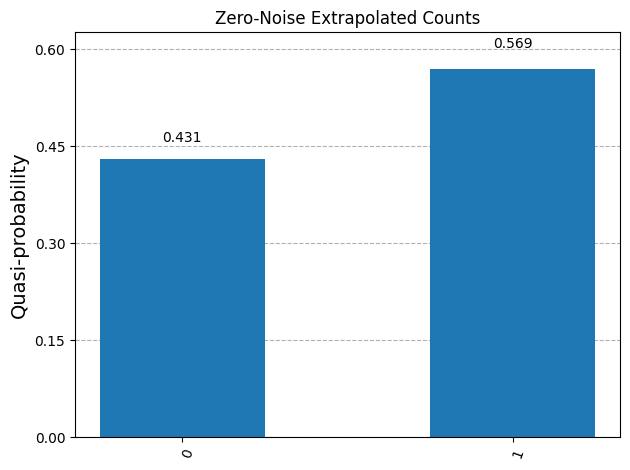

In [8]:
# 결과 그리기
plt.figure(figsize=(10, 6))
plot_histogram(zne_counts, title="Zero-Noise Extrapolated Counts")
plt.show()

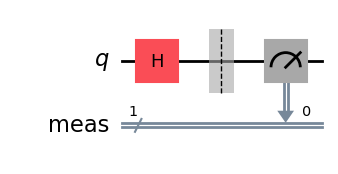

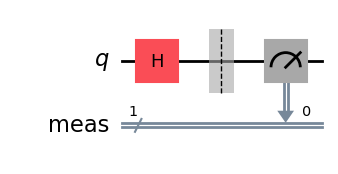

In [9]:
# 회로 시각화
qc.draw('mpl')